# **0. Definición de rutas y configuraciones base**

In [1]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import glob
import os

In [2]:
sns.set_theme(style = "whitegrid", palette = "tab10")
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

In [3]:
BASE = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "data"))

In [4]:
ATTACK_DIR  = os.path.join(BASE, "attack_traffic")
NORMAL_DIR  = os.path.join(BASE, "normal_traffic")

In [5]:
print("BASE DATA DIR:", BASE)

BASE DATA DIR: /home/nico/Desktop/Anomaly-Detection-IoT/data


# **1. Inventario de archivos**

In [6]:
attack_files  = sorted(glob.glob(os.path.join(ATTACK_DIR, "*.csv")))
normal_files  = sorted(glob.glob(os.path.join(NORMAL_DIR, "*", "*.csv")))

In [7]:
def file_info(paths):

    rows = []

    for p in paths:
        size_mb = os.path.getsize(p) / 1e6
        rows.append({"FILE": os.path.basename(p), "SIZE_MB": round(size_mb, 2), "PATH": p})
    
    return pd.DataFrame(rows)

In [8]:
print(f"ATTACK FILES: {len(attack_files)}")
print(f"NORMAL FILES: {len(normal_files)}")

ATTACK FILES: 14
NORMAL FILES: 10


In [9]:
display(file_info(attack_files))

,FILE,SIZE_MB,PATH
0,Backdoor_attack.csv,17.89,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
1,DDoS_HTTP_Flood_attack.csv,95.71,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
2,DDoS_ICMP_Flood_attack.csv,892.08,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
3,DDoS_TCP_SYN_Flood_attack.csv,941.19,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
4,DDoS_UDP_Flood_attack.csv,900.23,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
5,MITM_attack.csv,0.33,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
6,OS_Fingerprinting_attack.csv,0.31,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
7,Password_attack.csv,653.29,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
8,Port_Scanning_attack.csv,7.34,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
9,Ransomware_attack.csv,7.59,/home/nico/Desktop/Anomaly-Detection-IoT/data/...


In [10]:
display(file_info(normal_files))

,FILE,SIZE_MB,PATH
0,Distance.csv,366.06,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
1,Flame_Sensor.csv,343.52,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
2,Heart_Rate.csv,52.57,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
3,IR_Receiver.csv,412.74,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
4,Modbus.csv,67.90,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
5,Soil_Moisture.csv,381.59,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
6,Sound_Sensor.csv,478.97,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
7,Temperature_and_Humidity.csv,922.59,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
8,Water_Level.csv,731.46,/home/nico/Desktop/Anomaly-Detection-IoT/data/...
9,phValue.csv,237.33,/home/nico/Desktop/Anomaly-Detection-IoT/data/...


# **2. Carga y conteo de registros por archivo**

In [11]:
def count_rows(paths, label):

    records = []
    
    for p in paths:
        name = os.path.basename(p).replace(".csv", "")
        n = sum(1 for _ in open(p)) - 1  
        records.append({"TYPE": label, "DATASET": name, "REGISTERS": n})
        
    return pd.DataFrame(records)

In [12]:
df_counts_attack = count_rows(attack_files, "ATTACK")
df_counts_normal = count_rows(normal_files, "NORMAL")

In [13]:
display(df_counts_normal.sort_values("REGISTERS", ascending = False))

,TYPE,DATASET,REGISTERS
8,NORMAL,Water_Level,2295288
7,NORMAL,Temperature_and_Humidity,1615722
6,NORMAL,Sound_Sensor,1512883
3,NORMAL,IR_Receiver,1307778
5,NORMAL,Soil_Moisture,1192777
0,NORMAL,Distance,1143540
1,NORMAL,Flame_Sensor,1070196
9,NORMAL,phValue,746908
2,NORMAL,Heart_Rate,165319
4,NORMAL,Modbus,159502


In [14]:
display(df_counts_attack.sort_values("REGISTERS", ascending = False))

,TYPE,DATASET,REGISTERS
4,ATTACK,DDoS_UDP_Flood_attack,3201626
2,ATTACK,DDoS_ICMP_Flood_attack,2914354
3,ATTACK,DDoS_TCP_SYN_Flood_attack,2020120
7,ATTACK,Password_attack,1053385
1,ATTACK,DDoS_HTTP_Flood_attack,229022
12,ATTACK,Vulnerability_scanner_attack,145869
10,ATTACK,SQL_injection_attack,51203
11,ATTACK,Uploading_attack,37634
0,ATTACK,Backdoor_attack,24862
8,ATTACK,Port_Scanning_attack,22564


# **3. Carga completa del conjunto de datos combinado**

In [15]:
SAMPLE_THRESHOLD = 500_000  
SAMPLE_N = 100_000

In [16]:
def load_csv(path, reduce = False):

    if reduce:
        n_rows = sum(1 for _ in open(path)) - 1
        
        if n_rows > SAMPLE_THRESHOLD:
            df = pd.read_csv(path, skiprows = lambda i: i > 0 and np.random.rand() > SAMPLE_N / n_rows, low_memory = False)
            print(f"[SAMPLING] {os.path.basename(path)}: {n_rows:,} → {len(df):,} ROWS")
    
        else:
            df = pd.read_csv(path, low_memory = False)

    else:
        df = pd.read_csv(path, low_memory = False)
    
    return df

In [17]:
print("LOADING ATTACK FILES ...")
parts_attack = [load_csv(p) for p in attack_files]

LOADING ATTACK FILES ...


In [18]:
print("LOADING NORMAL FILES ...")
parts_normal = [load_csv(p) for p in normal_files]

LOADING NORMAL FILES ...


In [19]:
df = pd.concat(parts_attack + parts_normal, ignore_index = True)
print(f"\nCOMBINED DATASET: {df.shape[0]:,} ROWS × {df.shape[1]} COLUMNS")


COMBINED DATASET: 20,939,622 ROWS × 63 COLUMNS


In [20]:
df.columns

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len

In [21]:
STR_COLS = {"frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4",
            "arp.dst.proto_ipv4", "tcp.checksum", "tcp.options", "tcp.payload",
            "tcp.flags", "http.file_data", "http.request.uri.query",
            "http.request.method", "http.referer", "http.request.full_uri",
            "http.request.version", "dns.qry.name", "mqtt.msg_decoded_as",
            "mqtt.msg", "mqtt.protoname", "mqtt.topic", "Attack_type"}

In [22]:
num_cols = [c for c in df.columns if c not in STR_COLS]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors = "coerce")

In [23]:
print("CASTING TO NUMERICAL DONE\n")
print(df.dtypes.value_counts())

CASTING TO NUMERICAL DONE

float64    42
object     18
str         2
int64       1
Name: count, dtype: int64


# **4. Estructura y tipos de datos**

In [24]:
print(df.dtypes.value_counts())

float64    42
object     18
str         2
int64       1
Name: count, dtype: int64


In [25]:
df.info(memory_usage = "deep", verbose = False)

<class 'pandas.DataFrame'>
RangeIndex: 20939622 entries, 0 to 20939621
Columns: 63 entries, frame.time to Attack_type
dtypes: float64(42), int64(1), object(18), str(2)
memory usage: 25.1 GB


# **5. Distribución de clases**

In [26]:
class_counts = df["Attack_label"].value_counts().rename({0: "NORMAL", 1: "ATTACK"})
class_pct    = class_counts / class_counts.sum() * 100

In [27]:
summary = pd.DataFrame({"REGISTRIES": class_counts, "PERCENTAGE": class_pct.round(2)})
display(summary)

,REGISTRIES,PERCENTAGE
Attack_label,,
NORMAL,11209913,53.53
ATTACK,9729709,46.47


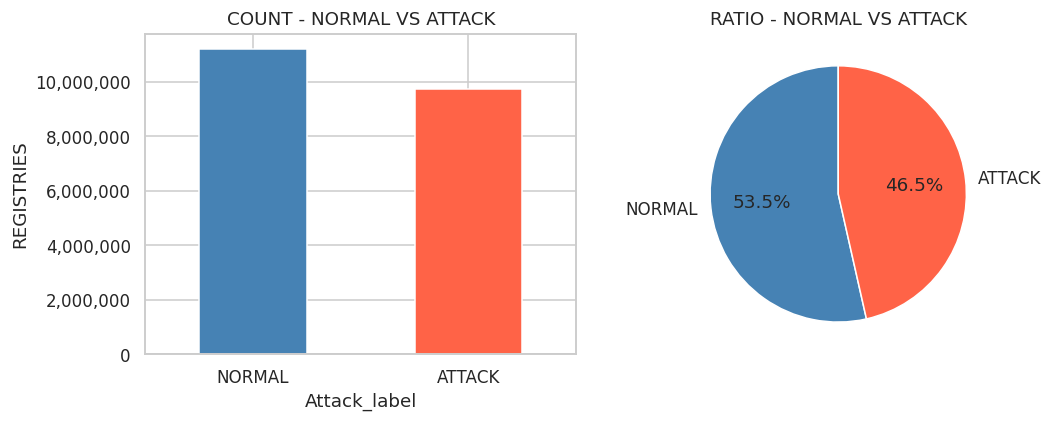

In [28]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))

class_counts.plot.bar(ax = axes[0], color = ["steelblue", "tomato"], rot = 0)

axes[0].set_title("COUNT - NORMAL VS ATTACK")
axes[0].set_ylabel("REGISTRIES")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors = ["steelblue", "tomato"], startangle = 90)
axes[1].set_title("RATIO - NORMAL VS ATTACK")

plt.tight_layout()
plt.show()

# **6. Distribución por tipo de ataque**

In [29]:
attack_type_counts = df["Attack_type"].value_counts()
display(attack_type_counts.rename("REGISTRIES").to_frame())

,REGISTRIES
Attack_type,
Normal,11209913
DDoS_UDP,3201626
DDoS_ICMP,2914354
DDoS_TCP,2020120
Password,1053385
DDoS_HTTP,229022
Vulnerability_scanner,145869
SQL_injection,51203
Uploading,37634


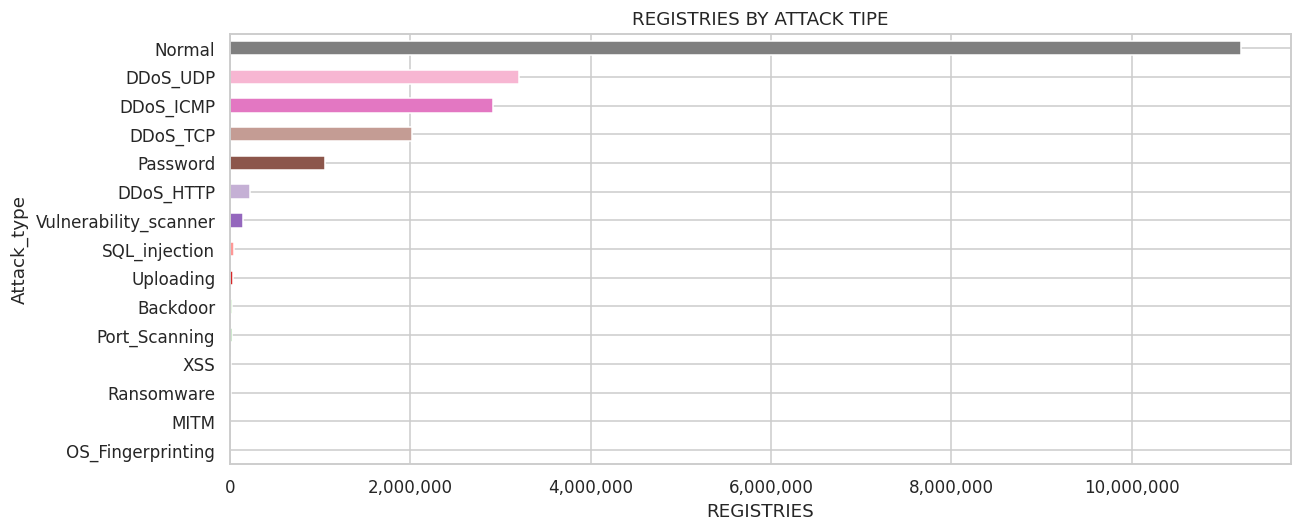

In [30]:
fig, ax = plt.subplots(figsize = (12, 5))

attack_type_counts.sort_values().plot.barh(ax = ax, color = sns.color_palette("tab20", len(attack_type_counts)))

ax.set_xlabel("REGISTRIES")
ax.set_title("REGISTRIES BY ATTACK TIPE")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

# **7. Valores nulos**

In [31]:
null_counts = df.isnull().sum()
null_pct    = null_counts / len(df) * 100
null_df = pd.DataFrame({"NULLS": null_counts, "PCT_NULLS": null_pct.round(2)})
null_df = null_df[null_df["NULLS"] > 0].sort_values("PCT_NULLS", ascending = False)

In [32]:
print(f"COLUMNS WITH NULL VALUES: {len(null_df)} of {df.shape[1]}")
display(null_df.head(20))

COLUMNS WITH NULL VALUES: 19 of 63


,NULLS,PCT_NULLS
icmp.checksum,2914727,13.92
mqtt.hdrflags,2666531,12.73
mqtt.conflags,666874,3.18
mqtt.conack.flags,666553,3.18
icmp.seq_le,302577,1.44
tcp.dstport,155549,0.74
tcp.ack_raw,155543,0.74
dns.qry.name.len,1916,0.01
arp.opcode,7,0.00
arp.hw.size,666,0.00


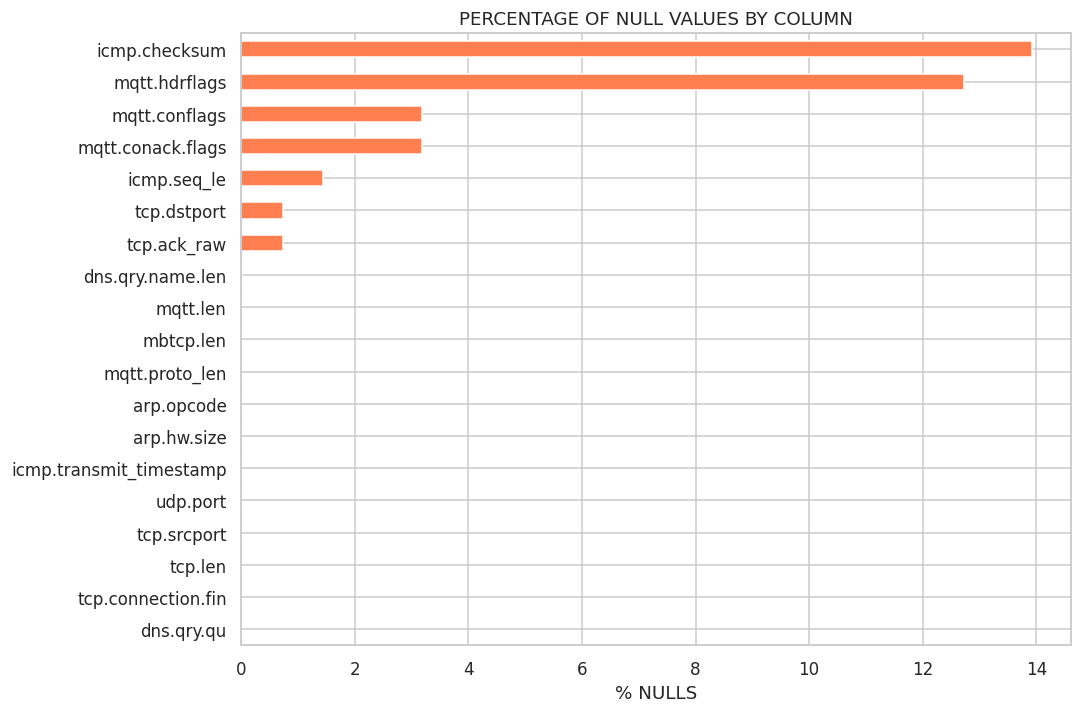

In [33]:
if not null_df.empty:

    fig, ax = plt.subplots(figsize=(10, max(4, len(null_df) * 0.35)))
    null_df["PCT_NULLS"].sort_values().plot.barh(ax = ax, color = "coral")
    ax.set_xlabel("% NULLS")
    ax.set_title("PERCENTAGE OF NULL VALUES BY COLUMN")
    plt.tight_layout()
    plt.show()

In [34]:
NUMERIC_COLS = [
    "tcp.len", "tcp.srcport", "tcp.dstport",
    "udp.port", "udp.time_delta",
    "icmp.seq_le",
    "mqtt.len", "mqtt.msgtype",
    "mbtcp.len",
    "http.content_length",
]

In [35]:
cols_present = [c for c in NUMERIC_COLS if c in df.columns]
display(df[cols_present].describe().T)

,count,mean,std,min,25%,50%,75%,max
tcp.len,20939233.0,27.515496,184.227304,0.0,0.0,0.0,0.0,65228.0
tcp.srcport,20939246.0,24160.438580,25927.645043,0.0,1883.0,4321.0,53005.0,65535.0
tcp.dstport,20784073.0,18512.034707,25699.503404,0.0,0.0,1883.0,51077.0,65535.0
udp.port,20939613.0,5.821528,533.003425,0.0,0.0,0.0,0.0,63894.0
udp.time_delta,20939622.0,0.055787,30.643140,0.0,0.0,0.0,0.0,52570.0
icmp.seq_le,20637045.0,4627.100714,13396.681902,0.0,0.0,0.0,0.0,65535.0
mqtt.len,20939621.0,1.321973,5.354693,0.0,0.0,0.0,0.0,49.0
mqtt.msgtype,20939622.0,0.636657,2.505876,0.0,0.0,0.0,0.0,14.0
mbtcp.len,20939621.0,114.201593,1926.128066,0.0,0.0,0.0,0.0,48900.0
http.content_length,20939622.0,4.303663,85.249905,0.0,0.0,0.0,0.0,83655.0


# **9. Análisis por protocolo de red**

In [36]:
protocol_flags = {
    "TCP"    : df["tcp.len"].notna() & (df["tcp.len"] != 0),
    "UDP"    : df["udp.port"].notna() & (df["udp.port"] != 0),
    "ICMP"   : df["icmp.checksum"].notna() & (df["icmp.checksum"] != 0),
    "HTTP"   : df["http.request.method"].notna() & (df["http.request.method"] != 0),
    "MQTT"   : df["mqtt.msgtype"].notna() & (df["mqtt.msgtype"] != 0),
    "Modbus" : df["mbtcp.len"].notna() & (df["mbtcp.len"] != 0),
    "DNS"    : df["dns.qry.name"].notna() & (df["dns.qry.name"] != 0),
    "ARP"    : df["arp.opcode"].notna() & (df["arp.opcode"] != 0),
}

In [37]:
proto_rows = []

for proto, mask in protocol_flags.items():

    sub = df[mask]
    normal_n = (sub["Attack_label"] == 0).sum()
    attack_n = (sub["Attack_label"] == 1).sum()
    proto_rows.append({"PROTOCOL": proto, "NORMAL": normal_n, "ATTACK": attack_n, "TOTAL": len(sub)})

proto_df = pd.DataFrame(proto_rows).sort_values("TOTAL", ascending = False)
display(proto_df)

,PROTOCOL,NORMAL,ATTACK,TOTAL
0,TCP,2859825,1603539,4463364
4,MQTT,2666530,0,2666530
3,HTTP,0,1533028,1533028
6,DNS,161367,302804,464171
5,Modbus,98090,0,98090
7,ARP,4775,3714,8489
1,UDP,5406,367,5773
2,ICMP,0,0,0


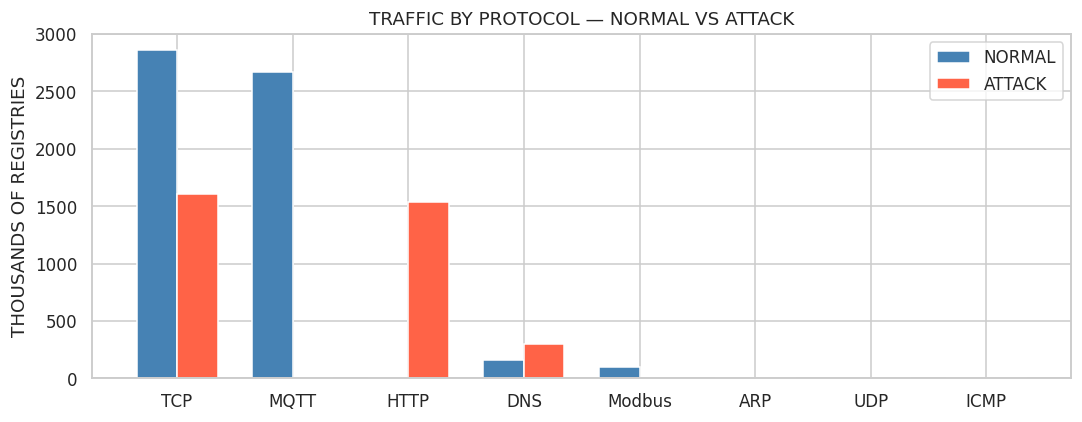

In [38]:
fig, ax = plt.subplots(figsize = (10, 4))

x = range(len(proto_df))
w = 0.35

ax.bar([i - w/2 for i in x], proto_df["NORMAL"] / 1e3, w, label = "NORMAL", color = "steelblue")
ax.bar([i + w/2 for i in x], proto_df["ATTACK"] / 1e3, w, label = "ATTACK", color = "tomato")

ax.set_xticks(list(x))
ax.set_xticklabels(proto_df["PROTOCOL"])
ax.set_ylabel("THOUSANDS OF REGISTRIES")
ax.set_title("TRAFFIC BY PROTOCOL — NORMAL VS ATTACK")
ax.legend()

plt.tight_layout()
plt.show()

# **10. Resumen final**

In [39]:
total = len(df)
n_normal = (df["Attack_label"] == 0).sum()
n_attack = (df["Attack_label"] == 1).sum()
n_attack_types = df[df["Attack_label"] == 1]["Attack_type"].nunique()

In [40]:
print("=" * 45)
print("SUMMARY OF DATASET")
print("=" * 45)
print(f"TOTAL REGISTRIES: {total:>12,}")
print(f"NORMAL TRAFFIC: {n_normal:>12,}  ({n_normal/total*100:.1f}%)")
print(f"ATTACK TRAFFIC: {n_attack:>12,}  ({n_attack/total*100:.1f}%)")
print(f"TYPES OF ATTACKS: {n_attack_types:>12}")
print(f"TOTAL COLUMNS: {df.shape[1]:>12}")
print(f"COLUMNS WITH NULLS: {(df.isnull().sum() > 0).sum():>12}")
print("=" * 45)

SUMMARY OF DATASET
TOTAL REGISTRIES:   20,939,622
NORMAL TRAFFIC:   11,209,913  (53.5%)
ATTACK TRAFFIC:    9,729,709  (46.5%)
TYPES OF ATTACKS:           14
TOTAL COLUMNS:           63
COLUMNS WITH NULLS:           19
